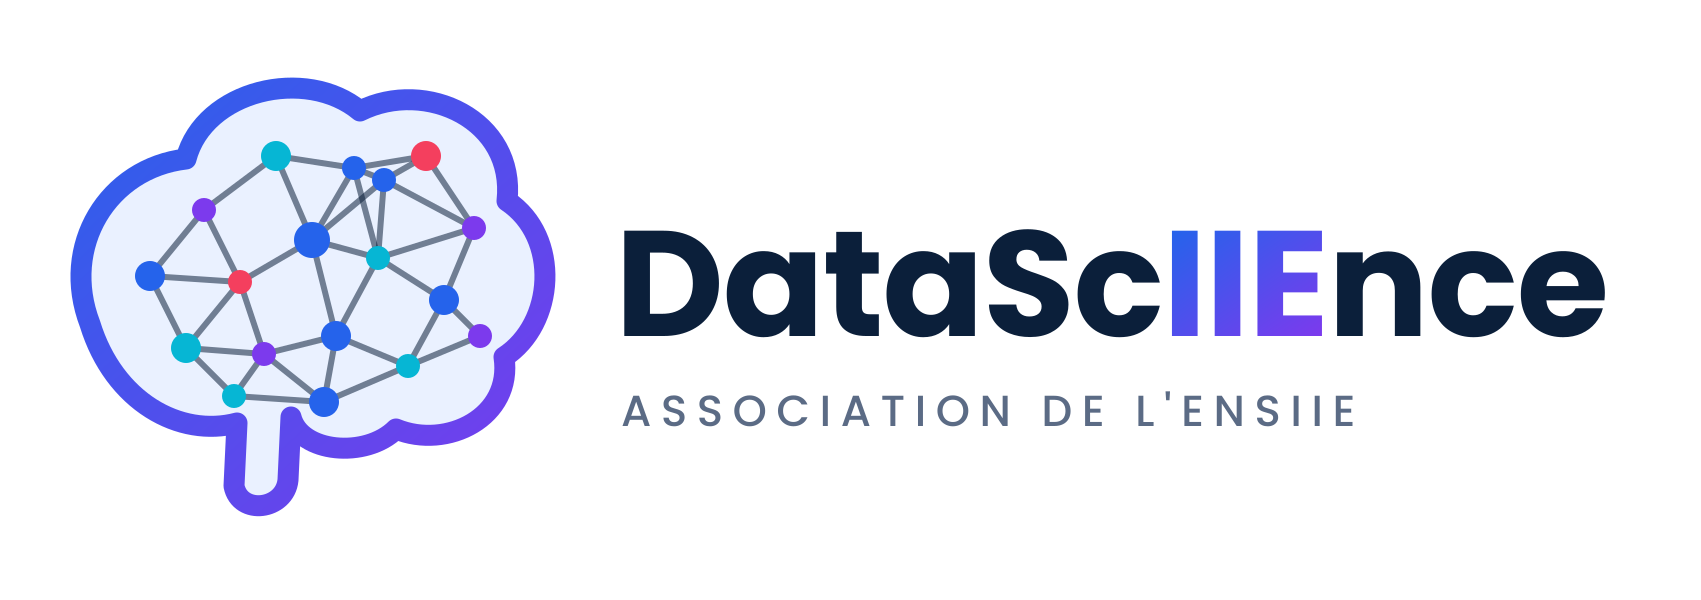

# Manipulation de Data Frame

## Importation de la bibliothèque

La bibliothèque que l'on utilise s'appelle **Pandas**.
On l'importe comme toute bibliothèque et on la renomme **pd** en général (alias pour pandas).

On aura aussi besoin de la bibliothèque **Numpy** (qu'on va renommer **np**)




In [ ]:
# importer Numpy et Pandas
import pandas as pd
import numpy as np

## Création
Il est possible de créer un DataFrame à partir d'un tableau Numpy.


In [ ]:
# céer un tableau numpy (3 lignes 4 colonnes) avec des valeurs aléatoires comprises entre 10 et 100
data = np.random.randint(10, 100, (3, 4))
data

La fonction [pandas.DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) permet de créer un DataFrame à partir du tableau data

In [ ]:
# créer un DataFrame à partir du tableau data
df = pd.DataFrame(data)
df

In [ ]:
# créer deux listes ind_ligne et ind_col
# ind_ligne contiendra les 'Apple' 'Facebook' et 'Amazon'
# ind_col contiendra 'T1','T2','T3' et 'T4'
ind_line = ['Apple','Facebook','Amazon']
ind_col = ['T1','T2','T3','T4']

In [ ]:
# recréer le DataFrame avec les bons indexes
df = pd.DataFrame(data, index=ind_line, columns=ind_col)
df

In [ ]:
Df = pd.DataFrame({'Yes': [5,2],'No': [12,6]})
Df

In [ ]:
Df = pd.DataFrame( {'Yes': [5,2],'No': [12,6]} , index = ['Option A', 'Option B'])
Df

On peut aussi créer des "Séries", si le DataFrame est un tableau, la série est la liste.

In [ ]:
S = pd.Series([6, 6, 3, 1, 5])
S

On peut aussi l'indexer

In [ ]:
S = pd.Series([52,43,11], index = ['Team A', 'Team B', 'Team C'], name = 'Team Points')
S

## Copie

In [ ]:
# copier le data frame
df2 = df.copy()
df2

In [ ]:
# copier une colonne
df2['T4bis'] = df2['T4']
# Colonne correspondant à la moyenne pour chaque ligne
df2['Mean'] = df2.mean(axis=1)
df2

## Sélection

In [ ]:
# NaN = Not a Number
df.isna()

In [ ]:
# on calcule le nombre de NaN par colonne
df.isna().sum()

In [ ]:
# localiser les éléments par indice de position
df.iloc[:1]

In [ ]:
df

In [ ]:
# récupérer la première colonne
df.iloc[:,0]

In [ ]:
# localiser les éléments par label de position
df.loc[:"Facebook"]

In [ ]:
df.loc[:,["T1","T2"]]

Choisir entre loc et iloc :

iloc utilise le schéma d'indexation Python stdlib, où le premier élément du
la plage est inclus et le dernier exclu. Ainsi 0:10 sélectionnera les entrées 0,...,9.

loc, quant à lui, indexe inclusivement. Ainsi 0:10 sélectionnera les entrées 0,...,10.

### À retenir

Un DataFrame est la structure principale de pandas : il représente un tableau de données à deux dimensions.<br>
Il se compose de lignes (index) et de colonnes (labels), chacune pouvant contenir un type de données différent.<br>
Les opérations de base incluent :<br>
    - la création (pd.DataFrame, pd.Series),<br>
    - la copie (.copy()),<br>
    - la sélection (.loc, .iloc),<br>
    - et la modification des données (ajout, suppression, renommage de colonnes).<br>

Les manipulations s’effectuent souvent sans modifier directement le DataFrame d’origine, sauf si inplace=True est précisé.<br>

# A vous de jouer!

- 1: Produire une fonction **generate_normal(n,m)**
    - Entrée: deux entiers naturels $n$ et $m$
    - Sortie: renvoie une DataFrame de n lignes nommées 'X1', 'X2', ..., 'Xn' et m colonnes 'Y1', 'Y2', ..., 'Ym'
    - Spec: la DataFrame sera remplie avec des réels suivant une distribution gaussienne (Vous serez souvent amenés à chercher en ligne certaines fonctions - Avoir ce réflexe sera à coup sûr très utile..).

- 2: Copier df dans une DataFrame df3. Ajouter des données pour un cinquième trimmestre (doit avoir une valeur manquante, à l'aide du mot clé **None**). Retrouver successivement les dataframes correspondant aux données:
    - de Facebook uniquement
    - d'Apple et d'Amazon
    - des deux derniers trimestres

- 3: Produire une fonction **est_pleine(df)**
    - Une dataframe df
    - Un booléen correspondant à l'affirmation "La dataframe est pleine."

- 4: Faire de même avec la fonction **est_vide(df)** (même si beaucoup moins utile en toute somme...)

In [ ]:
def generate_normal(n, m):
  X = ["X"+str(i+1) for i in range(n)]
  Y = ["X"+str(i+1) for i in range(m)]
  return pd.DataFrame(np.random.normal(0, 1, (n, m)), columns=Y, index=X)

df3 = df.copy()
df3['T5'] = [1, 2, None]

def est_pleine(df):
  return df.isna().sum().sum() == 0

def est_vide(df):
  return df.isna().sum().sum() == df.size

#Testing
print(generate_normal(3, 5))

presque_vide = pd.DataFrame({'Col1': [None, None, 1], 'Col2': [None, None, None]}, index=["Table", "un peu", "nulle."])
print([est_pleine(df), est_pleine(df3), est_vide(presque_vide), est_vide(presque_vide['Col2'])])
# [True, False, False, True]

# Sélectionner Sous Conditions

In [ ]:
# Renvoie une série de booléen
df.T1 == 27

In [ ]:
# Renvoie que les lignes où T1 vaut 79
df.loc[df.T1 == 79]

In [ ]:
# Renvoie seulement les lignes où la valeur de T2 est dans la liste donnée
df.loc[df.T2.isin([77, 16])]
df

In [ ]:
dict = {'T1': [100, np.nan, 95],
        'T2': [30, 45, np.nan],
        'T3': [40, 80, 98],
        'T4': [152,120,np.nan]}
df3 = pd.DataFrame(dict)
df3

In [ ]:
df3.loc[df3.T2.isnull()]

### À retenir

Les filtres conditionnels permettent d’extraire des sous-ensembles précis de données.<br>
On utilise les opérateurs logiques : & (ET), | (OU), ~ (NON).<br>

La syntaxe de base :<br>
df[(df["age"] > 30) & (df["ville"] == "Paris")]

Les conditions peuvent aussi être appliquées sur des chaînes (str.contains, isin) ou des dates.

Ce mécanisme est fondamental pour analyser et nettoyer efficacement un jeu de données.

## Informations sur dataframe
Il est possible d'obtenir les informations sur les colonnes grâce à [df.info](https://pandas.pydata.org/pandas-docs/version/0.23/generated/pandas.DataFrame.info.html).




In [ ]:
df.info()

In [ ]:
df.describe()

df.info() et df.describe() sont les deux outils de diagnostic essentiels pour comprendre la structure du DataFrame.<br>
Ces commandes permettent d’obtenir :<br>
- les types de données (int, float, object, datetime),<br>
- le nombre de valeurs manquantes,<br>
- les statistiques de base (moyenne, médiane, écart-type, etc.).<br>

Ces informations servent à orienter le prétraitement : typage, nettoyage, conversions et choix des analyses futures.

## Importation du data Frame

La première étape est d'identifier le type de fichier.

Il existe plusieurs extensions de fichiers:

1.   Les .csv (fichier textes où les éléments sont séparés par des virgules). Ce sont les fichiers qui sont le plus utilisés.

2.   Les .xls, les .json etc...

On importe les fichiers csv grâce à la fonction [pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html).
Les fichiers .xls grâce à la fonction  [pandas.read_table](https://pandas.pydata.org/docs/reference/api/pandas.read_table.html).


[pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) prend en argument le chemin du fichier (ou juste son nom s'il se situe dans le même dossier que le fichier code), le type de séparation, l'option d'affichage et encore plein d'autres éléments qui sont développés dans la documentation.

Les attributs [head](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html) et [tail](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.tail.html) permettent d'afficher les premières et les dernières données.

Nous allons travailler avec la base de données du Titanic


















In [ ]:
# importation des données
df_titanic = pd.read_csv("titanic.csv")

In [ ]:
# connaître les dimensions de notre data frame
df_titanic.shape

In [ ]:
# afficher les types
df_titanic.dtypes

In [ ]:
# visualisation des 5 premières lignes
df_titanic.head()

In [ ]:
# si on veut préciser le nombre de lignes
df_titanic.head(2)

In [ ]:
# Visualisation des 5 dernières données
df_titanic.tail()

## Manipulation d'un DataFrame



In [ ]:
# voir il y a combien de valeurs manquantes pour chaque colonne
df_titanic.isna().sum()

In [ ]:
# on veut changer la colonne Sex de valeurs {'male','female'} en {0,1}
df_titanic['Sex'] = df_titanic.loc[:,'Sex'].apply(lambda x: 1 if(x=='male') else 2)
df_titanic

In [ ]:
# même chose que apply
df_titanic['Sex'] = df_titanic.loc[:,'Sex'].map(lambda x: 1 if(x=='male') else 2)
df_titanic.head()

In [ ]:
# la colonne Cabin contient beaucoup de valeurs manquantes on la supprime
df_titanic.drop('Cabin', inplace=True, axis=1)
df_titanic

In [ ]:
# on remplace les valeurs manquantes dans Age par la moyenne
df_titanic['Age'].fillna(df_titanic['Age'].mean(), inplace=True)

In [ ]:
# on élimine les lignes contenant Nan dans Embarked
df_titanic.dropna(inplace=True)

In [ ]:
# on veut connaître la moyenne d'âge des personnes ayant survécu
df_titanic[df_titanic['Survived'] == 1].Age.mean()

Récap de fonction:

**describe():** renvoie un résumé du data set

**mean():** renvoie la moyenne

**unique():** renvoie une liste de valeur unique

**value_count():** renvoie une liste de valeur unique et le nombre d'occurence de chacune des valeurs

### À retenir

Manipuler un DataFrame consiste à modifier, enrichir ou nettoyer les données :<br>
- créer/supprimer/renommer des colonnes (df["new"] = ..., df.drop()),<br>
- gérer les valeurs manquantes (dropna, fillna),<br>
- transformer les types (astype),<br>
- et appliquer des fonctions (apply, map, lambda).<br>

Ces opérations constituent le cœur de la préparation des données avant toute analyse ou modélisation.


## Tri et Groupement

In [ ]:
Embark = df_titanic.groupby('Embarked').PassengerId.count()
Embark

In [ ]:
df_titanic.groupby('Age').Age.count()

In [ ]:
df_titanic.groupby(['Embarked']).Age.agg([len, min, np.mean, max])

In [ ]:
df_titanic.sort_values(by = 'Name', ascending=False)

### À retenir

Le tri (sort_values) permet d’organiser les données selon une ou plusieurs colonnes.
Le groupement (groupby) est une étape clé pour résumer les données :
-compter (count), sommer (sum), calculer des moyennes (mean), etc.

On peut combiner plusieurs agrégations avec .agg() :<br>
df.groupby("categorie").agg({"prix": ["mean", "sum"]})


reset_index() permet de revenir à un format tabulaire classique après un groupby.


# A vous de jouer!

- 1: Petit échauffement:
  - Réimporter les données de "titanic.csv" dans une dataframe df4
  - Supprimer toutes les données catégorielles
  - Quels passagers sont plus âgés que la moyenne et combien sont-ils en proportion?

- 2: Préjugé ou pas? - Les vieux à bord d'un bateau sont riches (s'inspirer de la question précédente).

- 3: Vérifier à l'aide d'une aggrégation, qu'il y a pratiquement autant de survivants que de décès parmi les mineurs (la majorité se faisant à 21 ans à l'époque).
  

In [ ]:
df4 = pd.read_csv("titanic.csv")

df4.drop(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], inplace=True, axis=1)
# or df4 = df4.select_dtypes(exclude=['object'])
vieux = df4[df4['Age'] > df4['Age'].mean()]
print(len(vieux) * 100 / len(df4))

v_riches = vieux[vieux['Fare'] > vieux['Fare'].mean()]
print(len(v_riches) * 100 / len(vieux))

df4[df4['Age'] < 21].groupby("Survived").Age.count()

## Visualisation des données

In [ ]:
# histogramme
hist = df_titanic['Age'].hist()

In [ ]:
# les corrélations entre les variables numériques
df_titanic_corr = df_titanic.drop(['Ticket', 'Name'], axis=1)
df_titanic_corr['Embarked'] = df_titanic_corr.loc[:,'Embarked'].map(lambda x: ['S', 'C', 'Q'].index(x))
df_titanic_corr.corr()
# pas de corrélation ici

Plus un coefficient de corrélation est proche de 1 en valeur absolue, plus les deux variables concernées sont corrélées (i.e. dépendantes). À l'inverse, plus ce coefficient est proche de 0, plus on peut considérer les variables comme indépendantes

# Pour réviser (et aller plus loin)

https://www.kaggle.com/learn/pandas